In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import os
from src.modeling import load_model

from src.modeling import (
    prepare_train_test
)

from src.evaluation import (
    ClassificationEvaluator
)

from src.visualization import (
    ClassificationVisualizer
)

from src.utils import (
    load_pickle,
    create_directory
)


In [3]:
# Load Data

df = pd.read_csv(r"D:\GIT\data-analytics-portfolio\02-telco-customer-churn\data\processed\telco_customer_churn_model_data.csv")

df.head()

,seniorcitizen,tenure,monthlycharges,totalcharges,charge_per_month_tenure,num_additional_services,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,...,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn,tenure_group_developing,tenure_group_established,tenure_group_loyal,charge_band_medium,charge_band_high,charge_band_premium
0,0,1,29.85,29.85,14.925000,1,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
1,0,34,56.95,1889.50,53.985714,2,True,False,False,True,...,False,False,True,False,False,True,False,True,False,False
2,0,2,53.85,108.15,36.050000,2,True,False,False,True,...,False,False,True,True,False,False,False,True,False,False
3,0,45,42.30,1840.75,40.016304,3,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,0,2,70.70,151.65,50.550000,0,False,False,False,True,...,False,True,False,True,False,False,False,False,True,False


In [4]:
df["churn"].value_counts(normalize=True)

churn
False    0.735508
True     0.264492
Name: proportion, dtype: float64

In [5]:
# features and target

X = df.drop(
    columns="churn"
)

y = df["churn"]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = (
    prepare_train_test(
        X,
        y
    )
)

# verify
print(X_train.shape)
print(X_test.shape)



(5616, 38)
(1405, 38)


In [ ]:
# Load Models
log_model = load_model(
    "../models/logistic_regression.pkl"
)

rf_model = load_model(
    "../models/random_forest.pkl"
)

gb_model = load_model(
    "../models/gradient_boosting.pkl"
)

scaler = load_model(
    "../models/scaler.pkl"
)

xgb_model = load_model(
    "../models/xgboost.pkl"
)

In [8]:
# scale test data
X_test_scaled = scaler.transform(
    X_test
)


In [9]:
# Evaluate Logistic Regression Model
log_results = (
    ClassificationEvaluator
    .evaluate_model(
        log_model,
        X_test_scaled,
        y_test
    )
)

log_results

print(
    ClassificationEvaluator
    .classification_report_text(
        log_model,
        X_test_scaled,
        y_test
    )
)


              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1033
        True       0.68      0.52      0.59       372

    accuracy                           0.81      1405
   macro avg       0.76      0.72      0.73      1405
weighted avg       0.80      0.81      0.80      1405



In [10]:
# Evaluate Random Forest Model

rf_results = (
    ClassificationEvaluator
    .evaluate_model(
        rf_model,
        X_test,
        y_test
    )
)

rf_results

print(
    ClassificationEvaluator
    .classification_report_text(
        rf_model,
        X_test,
        y_test
    )
)



              precision    recall  f1-score   support

       False       0.83      0.91      0.86      1033
        True       0.64      0.47      0.55       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405



In [11]:
# Evaluate Gradient Boosting Model
gb_results = (
    ClassificationEvaluator
    .evaluate_model(
        gb_model,
        X_test,
        y_test
    )
)

gb_results

print(
    ClassificationEvaluator
    .classification_report_text(
        gb_model,
        X_test,
        y_test
    )
)


              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1033
        True       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



In [12]:
# Evaluate xgboost Model
xgb_results = (
    ClassificationEvaluator
    .evaluate_model(
        xgb_model,
        X_test,
        y_test
    )
)

xgb_results

print(
    ClassificationEvaluator
    .classification_report_text(
        xgb_model,
        X_test,
        y_test
    )
)


              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.49      0.55       372

    accuracy                           0.78      1405
   macro avg       0.72      0.69      0.70      1405
weighted avg       0.77      0.78      0.78      1405



In [13]:
# Result dictionary

results = {

    "Logistic Regression":
        log_results,

    "Random Forest":
        rf_results,

    "Gradient Boosting":
        gb_results,

    "XGBoost":
        xgb_results
}


In [14]:
# compare results
comparison_df = (
    ClassificationEvaluator
    .compare_models(
        results
    )
)

comparison_df

comparison_df.sort_values(
    by=[
        "Recall",
        "F1 Score"
    ],
    ascending=False
)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.807829,0.678322,0.521505,0.589666,0.716222
Gradient Boosting,0.799288,0.657343,0.505376,0.571429,0.705254
XGBoost,0.784342,0.616162,0.491935,0.547085,0.690789
Random Forest,0.791459,0.644689,0.473118,0.545736,0.689609


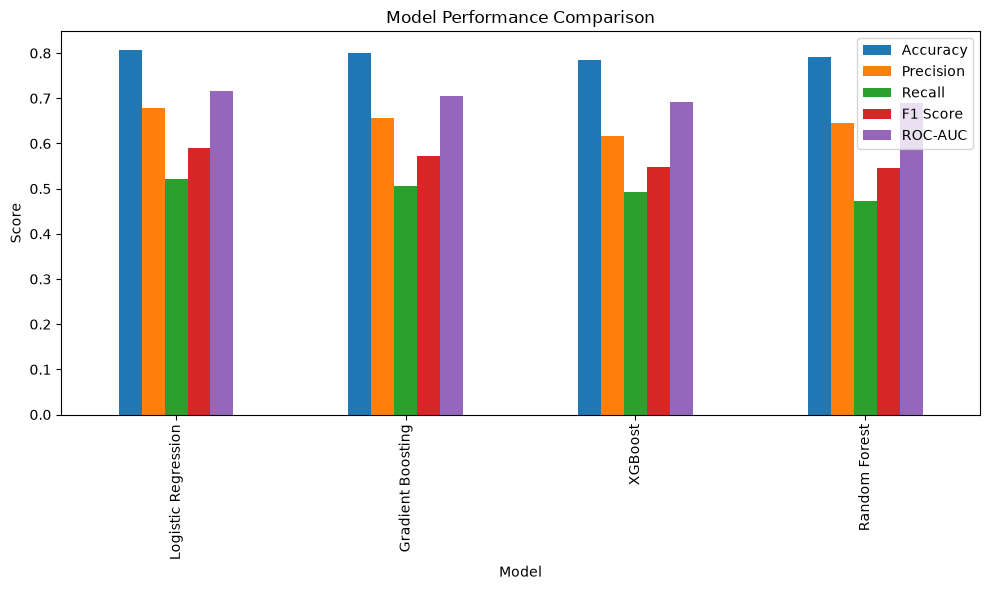

In [15]:
# visualize results
ClassificationVisualizer.model_comparison_chart(
    comparison_df.reset_index().rename(
        columns={
            "index":"Model"
        }
    )
)


## Best Model Selection

After evaluating Logistic Regression, Random Forest,
Gradient Boosting, and XGBoost, Logistic Regression
was selected as the final model.

Key results:

- Highest Accuracy (~81%)
- Highest Recall (~52%)
- Highest F1 Score (~59%)
- Highest ROC-AUC (~72%)

Recall was prioritized because the primary business
objective is to identify customers likely to churn.
Missing a churning customer (false negative) is more
costly than incorrectly flagging a customer as a
potential churner (false positive).

Therefore, Logistic Regression provides the best balance
between predictive performance and business value and is
recommended for deployment.

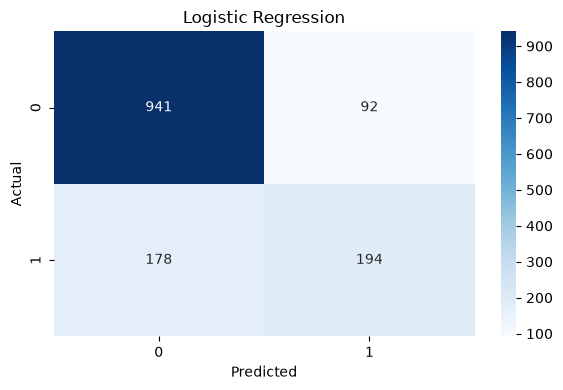

In [ ]:
# Logistic Regression Confusion Matrix
ClassificationVisualizer.plot_confusion_matrix(
    log_model,
    X_test_scaled,
    y_test,
    title="Logistic Regression"
)


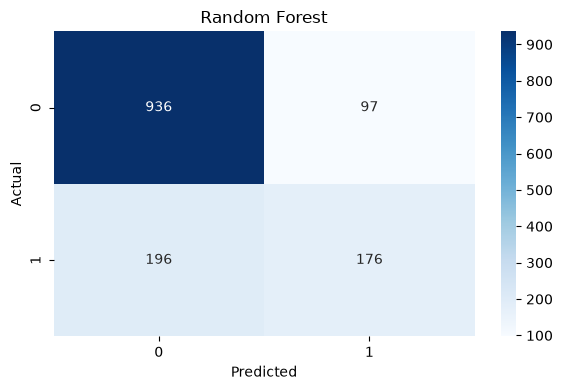

In [29]:
# Random Forest Confusion Matrix
ClassificationVisualizer.plot_confusion_matrix(
    rf_model,
    X_test,
    y_test,
    title="Random Forest",

    #save_path ="../visuals/model_evaluation/random_forest_cm.png"
)


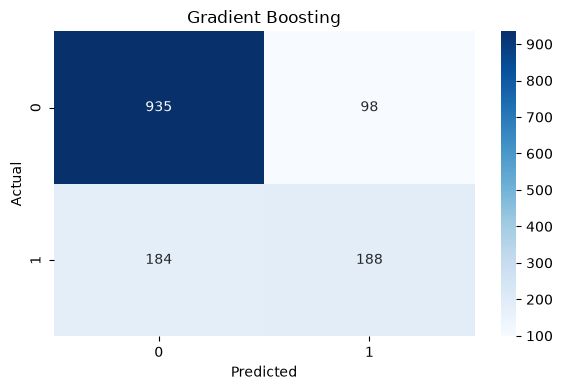

In [18]:
# Gradient Boosting Confusion Matrix
ClassificationVisualizer.plot_confusion_matrix(
    gb_model,
    X_test,
    y_test,
    title="Gradient Boosting"
)


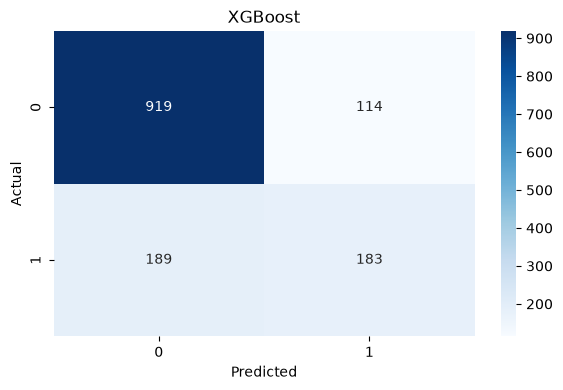

In [19]:
# XGBoost Confusion Matrix
ClassificationVisualizer.plot_confusion_matrix(
    xgb_model,
    X_test,
    y_test,
    title="XGBoost"
)


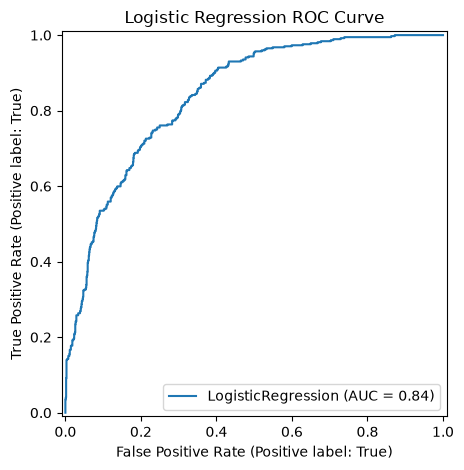

In [20]:
# Logistic Regression ROC Curve
ClassificationVisualizer.plot_roc_curve(
    log_model,
    X_test_scaled,
    y_test,
    title="Logistic Regression ROC Curve"
)



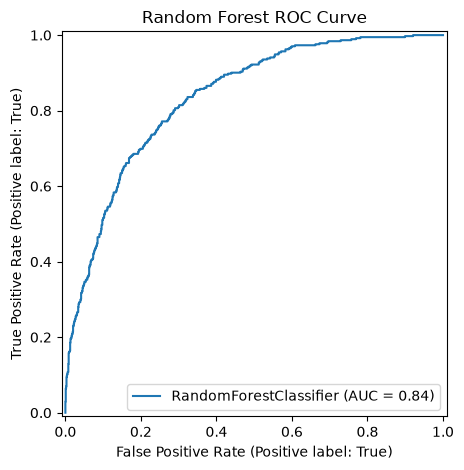

In [21]:
# Random Forest Roc Curve
ClassificationVisualizer.plot_roc_curve(
    rf_model,
    X_test,
    y_test,
    title="Random Forest ROC Curve"
)


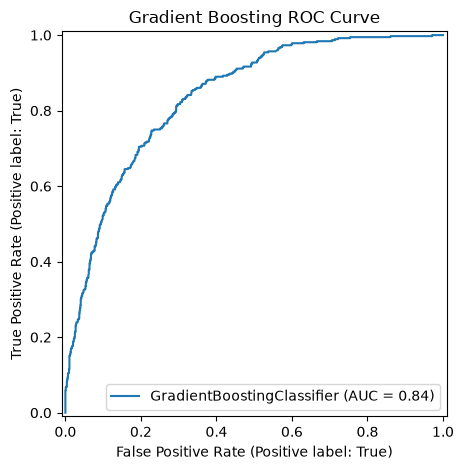

In [22]:
# Gradient Boosting Roc Curve
ClassificationVisualizer.plot_roc_curve(
    gb_model,
    X_test,
    y_test,
    title="Gradient Boosting ROC Curve"
)


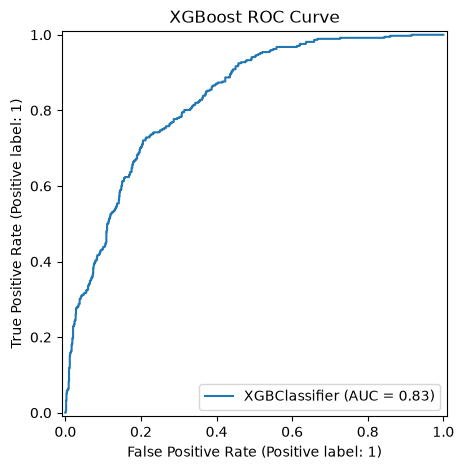

In [23]:
# XGBoost roc Curve
ClassificationVisualizer.plot_roc_curve(
    xgb_model,
    X_test,
    y_test,
    title="XGBoost ROC Curve"
)


In [24]:
create_directory(
    "../reports"
)

create_directory(
    "../visuals/model_evaluation"
)


WindowsPath('../visuals/model_evaluation')

In [25]:
# save comparison results to csv
comparison_df.to_csv(
    "../reports/model_performance.csv"
)
comparison_df


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.807829,0.678322,0.521505,0.589666,0.716222
Gradient Boosting,0.799288,0.657343,0.505376,0.571429,0.705254
XGBoost,0.784342,0.616162,0.491935,0.547085,0.690789
Random Forest,0.791459,0.644689,0.473118,0.545736,0.689609


In [26]:
comparison_df.sort_values(
    by=[
        "Recall",
        "F1 Score"
    ],
    ascending=False
)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.807829,0.678322,0.521505,0.589666,0.716222
Gradient Boosting,0.799288,0.657343,0.505376,0.571429,0.705254
XGBoost,0.784342,0.616162,0.491935,0.547085,0.690789
Random Forest,0.791459,0.644689,0.473118,0.545736,0.689609


# Business Interpretation

## Executive Summary

The objective of this analysis was to identify the machine learning model that most effectively predicts customer churn. Multiple classification models were evaluated and compared using key performance metrics including Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

## Key Findings

### Model Performance Comparison

The evaluated models demonstrated varying strengths and weaknesses. Performance was assessed based on:

- **Accuracy**: Overall percentage of correct predictions.
- **Precision**: Ability to correctly identify actual churners among predicted churners.
- **Recall**: Ability to identify customers who are truly likely to churn.
- **F1 Score**: Balance between Precision and Recall.
- **ROC-AUC**: Ability of the model to distinguish between churners and non-churners.

### Most Important Metric: Recall

For customer churn prediction, **Recall is the primary metric** because the business cost of missing a potential churn customer is high.

A low Recall score means:

- Many churn-prone customers are incorrectly classified as loyal.
- Retention interventions are not applied to at-risk customers.
- Customer losses may increase.

Therefore, the model with the highest Recall, while maintaining a reasonable F1 Score and ROC-AUC, is generally preferred for deployment.

## False Positives vs False Negatives

### False Positive

A customer is predicted to churn but actually stays.

Business impact:

- Possible unnecessary retention incentives.
- Small increase in retention costs.

### False Negative

A customer is predicted not to churn but actually leaves.

Business impact:

- Lost revenue.
- Lost future customer value.
- Missed opportunity for intervention.

Because the cost of a False Negative is typically higher, reducing False Negatives is a key objective of the model selection process.

## Recommended Production Model

Based on the evaluation metrics, the recommended production model is the one that best balances:

1. High Recall
2. Strong F1 Score
3. High ROC-AUC
4. Acceptable Accuracy

This model is most effective at identifying customers who are likely to churn while maintaining overall prediction quality.

## Customer Retention Recommendations

Based on the churn prediction results, the business should:

- Target high-risk customers with retention campaigns.
- Offer personalized discounts or loyalty incentives.
- Improve customer support for at-risk segments.
- Monitor customers with declining engagement.
- Implement proactive outreach before contract renewal periods.

## Conclusion

The model evaluation process identified the most suitable model for predicting customer churn and supporting customer retention efforts. By prioritizing Recall and minimizing False Negatives, the organization can better identify customers at risk of leaving and take proactive actions to improve retention, reduce revenue loss, and increase long-term customer value.